In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


### Note 7


In [3]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people()
faces.data.shape

(13233, 2914)

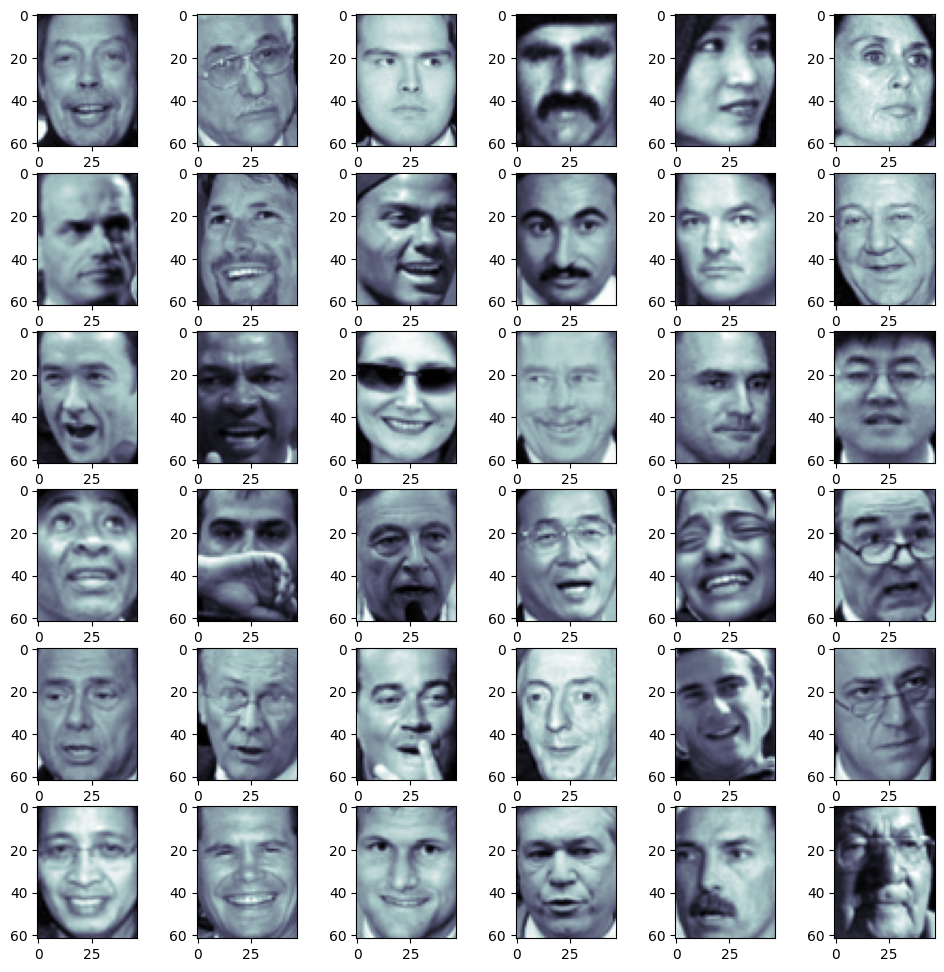

In [4]:
example_faces = faces.data[:36, :]

def plot_faces(data):
	plt.figure(figsize=(12, 12))
	for index, imageData in enumerate(data):
		plt.subplot(6, 6, index + 1)
		image = np.reshape(imageData, (62, 47))
		plt.imshow(image, cmap = 'bone')
	
	plt.show()

plot_faces(example_faces)


In [5]:
from sklearn.decomposition import PCA

pca = PCA(svd_solver='randomized')
pca.fit(faces.data)

pca.components_.shape

(2914, 2914)

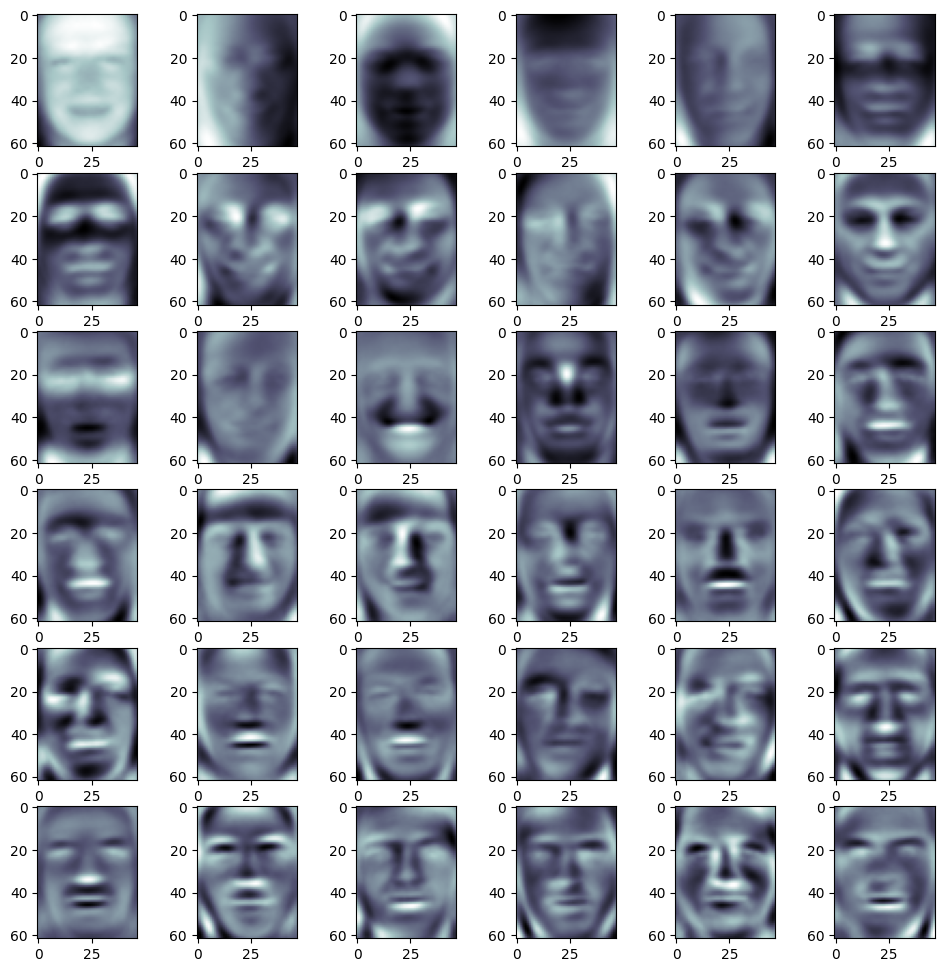

In [9]:
plot_faces(pca.components_[:36, :])

In [3]:
import matplotlib.pyplot as plt
import numpy as np

class FaceRecognizer:
    def __init__(self, retention):
        self.retention = retention
        self.face_data = None
        self.labels = None
        self.mean_face = None
        self.faces_less_mean = None
        self.eigenfaces = None
        self.weights = None

    def train(self):
        self.load_data()
        self.mean_face = np.average(self.face_data, axis=0)
        self.find_eigenfaces()
        self.weights = np.matmul(self.faces_less_mean, self.eigenfaces)

    def load_data(self):
        raw_data = np.genfromtxt('olivetti_faces_augmented.csv', delimiter=',')
        data_without_headers = np.delete(raw_data, 0, axis=0)
        self.labels = data_without_headers[:, -1]
        self.face_data = np.delete(data_without_headers, -1, axis=1)

    def find_eigenfaces(self):
        self.faces_less_mean = self.face_data - self.mean_face
        U, S, _ = np.linalg.svd(self.faces_less_mean.T)
        total_energy = S.sum()
        retention_candidates = np.where(S.cumsum() / total_energy > self.retention)
        dimensions_to_retain = retention_candidates[0][0]
        self.eigenfaces = U[:, 0:dimensions_to_retain]

    def reconstruct(self, weights):
        return np.matmul(weights, self.eigenfaces.T) + self.mean_face

    def find_best_match(self, face):
        face_less_mean = face - self.mean_face
        face_weights = np.matmul(face_less_mean, self.eigenfaces)
        diffs = self.weights - face_weights
        squared_diffs = diffs ** 2
        match_index = np.argmin(squared_diffs.sum(axis=1))
        return self.reconstruct(self.weights[match_index]), self.labels[match_index]




### Load ATT Faces Dataset

Training set: 360 images, Test set: 40 images
Image size: (112, 92)
Training matrix: (360, 10304), Test matrix: (40, 10304)


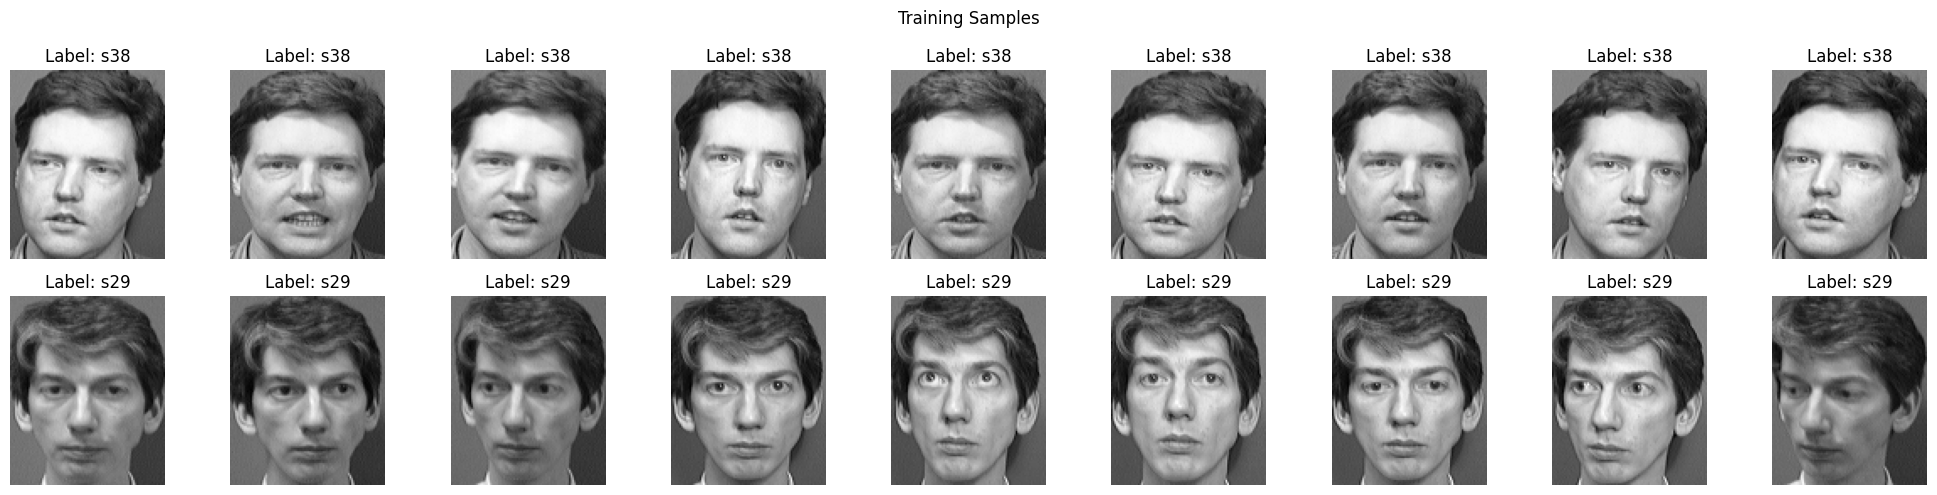

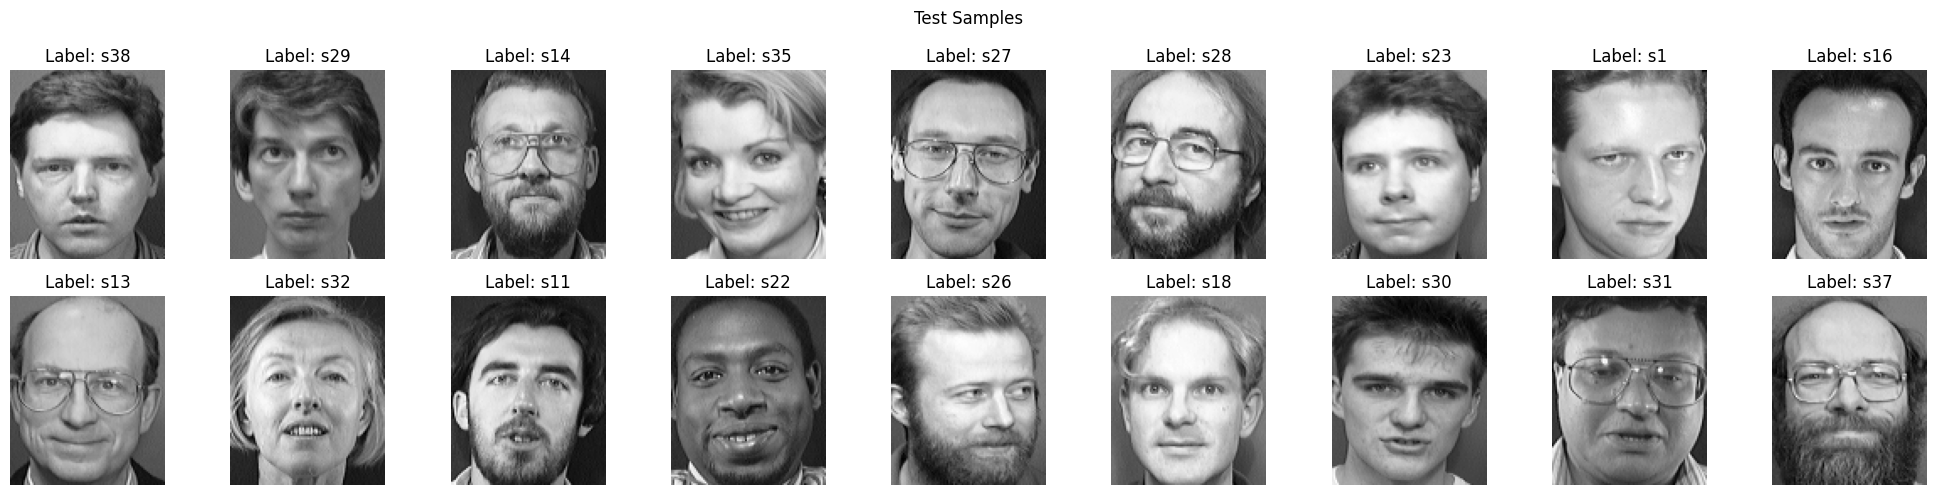

In [3]:
def load_images(path):
    images, labels = [], []
    for root, dirs, files in os.walk(path):
        for f in sorted(files):
            if f.endswith('.pgm'):
                img = Image.open(os.path.join(root, f))
                images.append(np.array(img, dtype=np.float64))
                labels.append(os.path.basename(root))  
    return images, labels

train_imgs, train_labels = load_images("Datasets/att_faces/Training")
test_imgs, test_labels = load_images("Datasets/att_faces/Testing")

print(f"Training set: {len(train_imgs)} images, Test set: {len(test_imgs)} images")
print(f"Image size: {train_imgs[0].shape}")

# Flatten into matrix (each row = one image)
X_train = np.array([img.flatten() for img in train_imgs])
X_test = np.array([img.flatten() for img in test_imgs])
y_train = np.array(train_labels)
y_test = np.array(test_labels)

print(f"Training matrix: {X_train.shape}, Test matrix: {X_test.shape}")

# Visualize samples
fig, axes = plt.subplots(2, 9, figsize=(20, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(train_imgs[i], cmap='gray')
    ax.set_title(f"Label: {train_labels[i]}")
    ax.axis('off')
plt.suptitle("Training Samples")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 9, figsize=(20, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(test_imgs[i], cmap='gray')
    ax.set_title(f"Label: {test_labels[i]}")
    ax.axis('off')
plt.suptitle("Test Samples")
plt.tight_layout()
plt.show()

### 

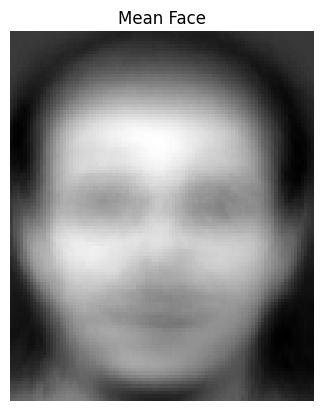

In [4]:
# ============================================================
# PCA Method for Face Recognition
# ============================================================

# Compute mean face 
mean_face = np.mean(X_train, axis=0)

# Visualize mean face
plt.imshow(mean_face.reshape(112, 92), cmap='gray')
plt.title("Mean Face")
plt.axis('off')
plt.show()



In [5]:
# Center the data
X_train_centered = X_train - mean_face
X_test_centered = X_test - mean_face

Covariance matrix shape: (360, 360)


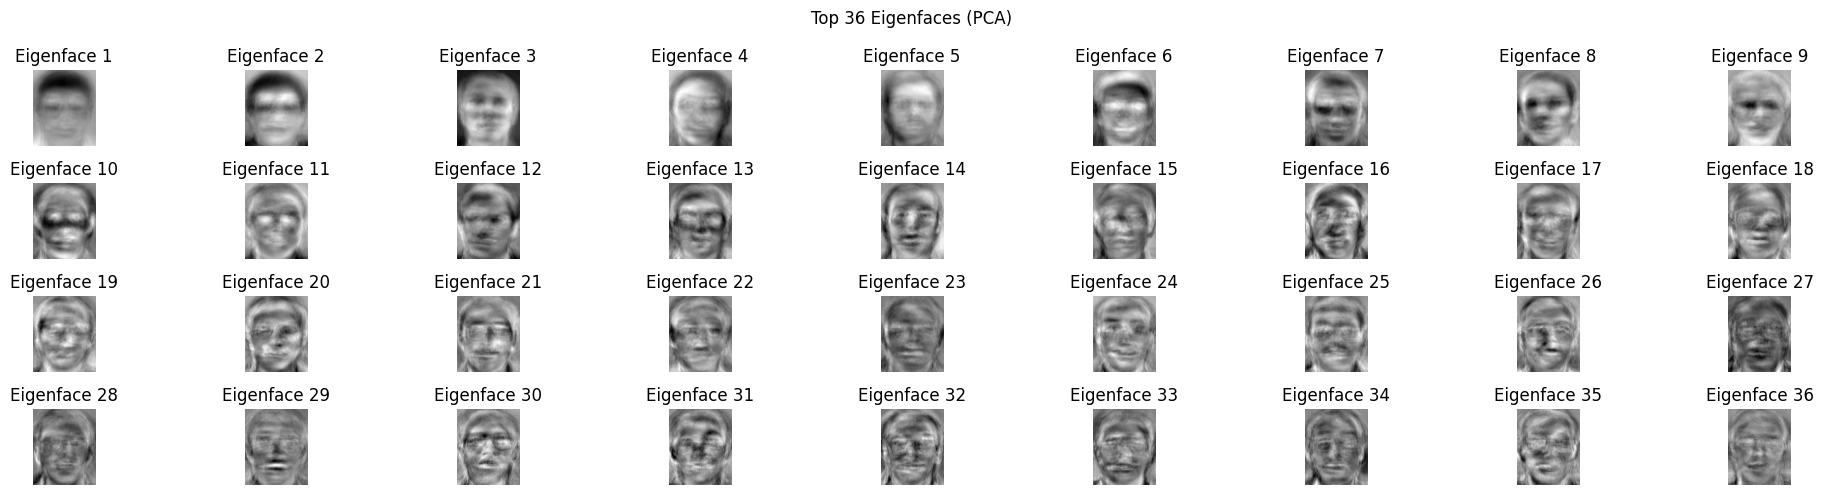

In [6]:
# Compute covariance matrix 
n = X_train_centered.shape[0]
cov_matrix = (X_train_centered @ X_train_centered.T) / (n - 1)
print(f"Covariance matrix shape: {cov_matrix.shape}")

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort by eigenvalue descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
small_eigvecs = eigenvectors[:, idx]

eigenvectors = X_train_centered.T @ small_eigvecs  # (10304, 360)
# Normalize each eigenvector to unit length
eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0)

# Visualize top eigenfaces
fig, axes = plt.subplots(4, 9, figsize=(20, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(eigenvectors[:, i].reshape(112, 92), cmap='gray')
    ax.set_title(f"Eigenface {i+1}")
    ax.axis('off')
plt.suptitle("Top 36 Eigenfaces (PCA)")
plt.tight_layout()
plt.show()

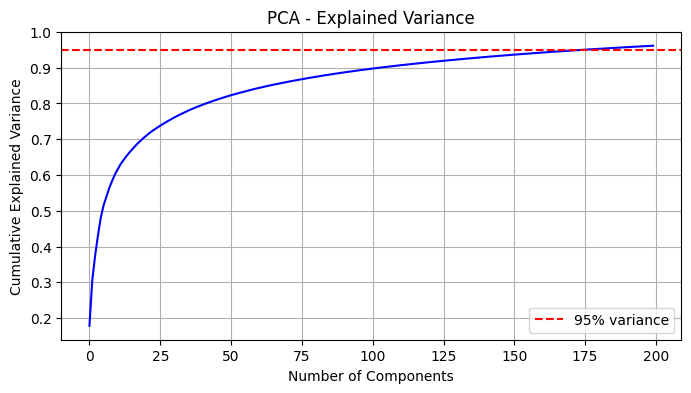

In [8]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8, 4))
plt.plot(cumulative_variance[:200], 'b-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

Components needed for 95% variance: 176
Projected training data: (360, 176)
Projected test data: (40, 176)

PCA Recognition Accuracy: 92.50%


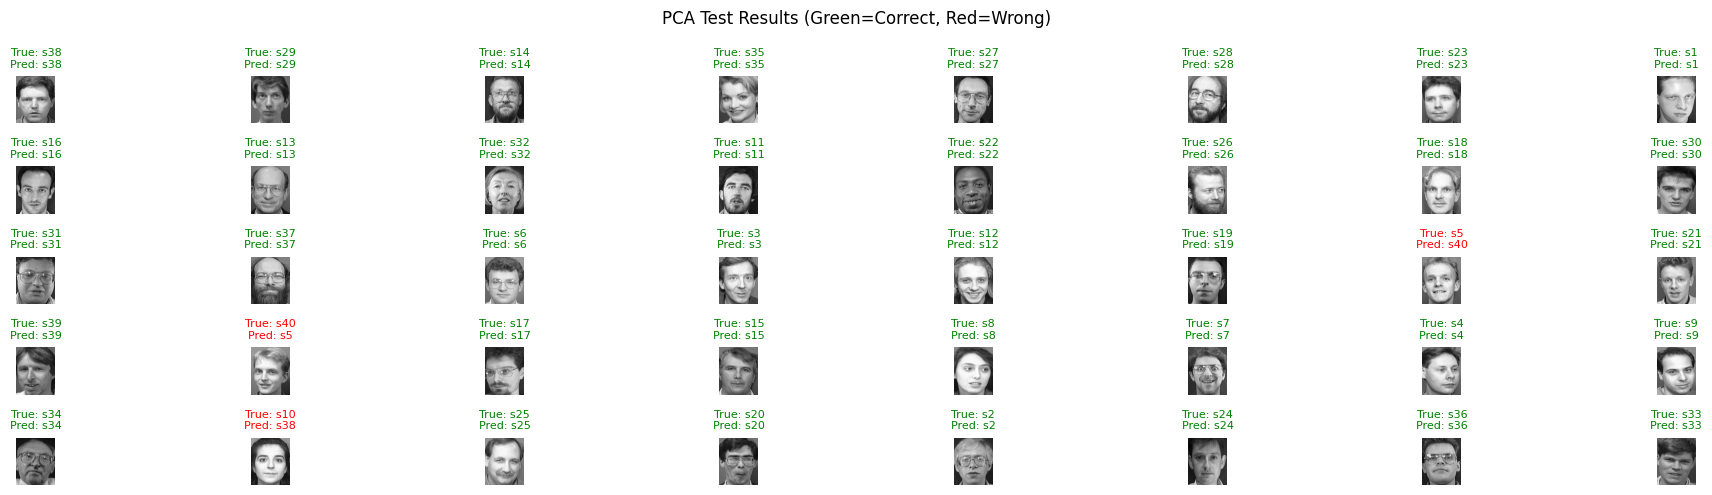

In [10]:
k_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {k_95}")

# Step 5: Project data to lower dimension
k = k_95  # or set manually, e.g. k = 50
W_pca = eigenvectors[:, :k]  # projection matrix (10304 x k)

X_train_pca = X_train_centered @ W_pca  # (360, k)
X_test_pca = X_test_centered @ W_pca    # (40, k)

print(f"Projected training data: {X_train_pca.shape}")
print(f"Projected test data: {X_test_pca.shape}")

# Step 6: Nearest neighbor classification
from scipy.spatial.distance import cdist

distances = cdist(X_test_pca, X_train_pca, metric='euclidean')
predictions = y_train[np.argmin(distances, axis=1)]

accuracy = np.mean(predictions == y_test)
print(f"\nPCA Recognition Accuracy: {accuracy * 100:.2f}%")

# Step 7: Show some test results
fig, axes = plt.subplots(5, 8, figsize=(20, 5))
for i, ax in enumerate(axes.flatten()):
    if i < len(test_imgs):
        ax.imshow(test_imgs[i], cmap='gray')
        color = 'green' if predictions[i] == y_test[i] else 'red'
        ax.set_title(f"True: {y_test[i]}\nPred: {predictions[i]}", fontsize=8, color=color)
    ax.axis('off')
plt.suptitle("PCA Test Results (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()